In [20]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

df  =load_iris(as_frame = True).frame
X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['petal width (cm)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
for k in [1,3,5,10,15,20]:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    model.fit(X_train, y_train)

    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    print(f"k={k}: Train R2={train_r2:.4f}, Test R2={test_r2:.4f}, Test RMSE={test_rmse:.4f}")

k=1: Train R2=1.0000, Test R2=0.9638, Test RMSE=0.1517
k=3: Train R2=0.9892, Test R2=0.9803, Test RMSE=0.1119
k=5: Train R2=0.9839, Test R2=0.9785, Test RMSE=0.1170
k=10: Train R2=0.9751, Test R2=0.9778, Test RMSE=0.1187
k=15: Train R2=0.9714, Test R2=0.9782, Test RMSE=0.1178
k=20: Train R2=0.9608, Test R2=0.9718, Test RMSE=0.1340


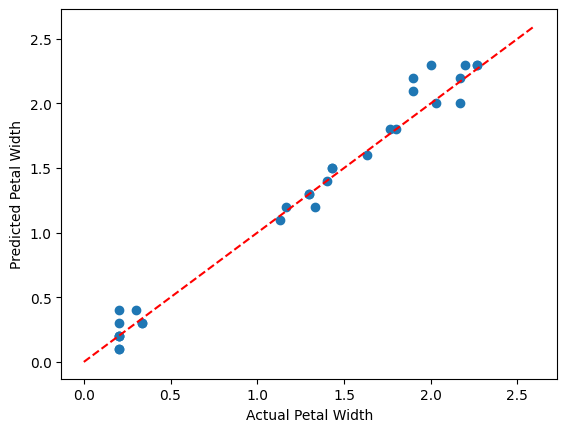

In [22]:
best = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=3))
best.fit(X_train, y_train)
pred = best.predict(X_test)

plt.scatter(pred, y_test)
plt.plot([0, 2.6], [0, 2.6], 'r--')  # Reference line for perfect predictions
plt.xlabel("Actual Petal Width")
plt.ylabel("Predicted Petal Width")
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), KNeighborsRegressor())
grid = GridSearchCV(pipe, {'kneighborsregressor__n_neighbors': [1, 3, 5, 10, 15, 20]},
                    cv=5, scoring='r2')
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)
print("test R2:", grid.score(X_test, y_test))

{'kneighborsregressor__n_neighbors': 3} 0.974821416197876
test R2: 0.9803061289890286
